In [7]:
import matplotlib.pyplot as plt
import math
from skimage.transform import rotate
from skimage.transform import EuclideanTransform
from skimage.transform import SimilarityTransform
from skimage.transform import matrix_transform
from skimage.transform import warp
from skimage.transform import swirl
from skimage import io, color

In [6]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/Ex7-GeometricTransformationsAndRegistration/data/"

/tmp/ipykernel_438459/272287634.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(rotated_img)
/tmp/ipykernel_438459/272287634.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


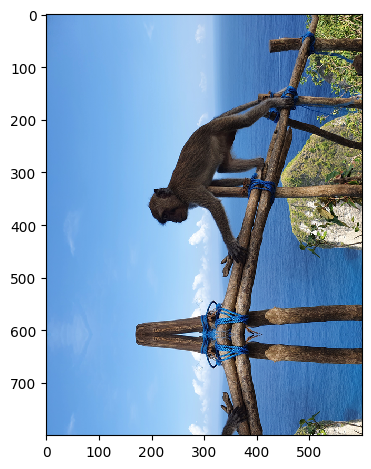

In [11]:
# Lx-7.1 Use skimage.transform.rotate to rotate an image using different rotation centers, different background filling strategies (constant, reflection, warping) and automatic scaling 

img = io.imread(path + "NusaPenida.png")

rotation_angle = 90
rotated_img = rotate(img, rotation_angle)


rot_centers = [5,5]

rotated_img = rotate(img, rotation_angle, center = rot_centers, mode = "reflect")

io.imshow(rotated_img)
io.show()



[[ 0.98480775 -0.17364818 10.        ]
 [ 0.17364818  0.98480775 20.        ]
 [ 0.          0.          1.        ]]


/tmp/ipykernel_438459/2701557258.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(transformed_img)
/tmp/ipykernel_438459/2701557258.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


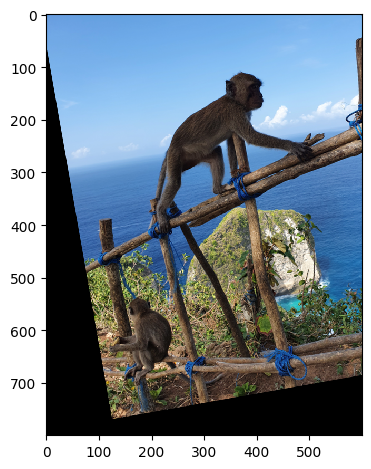

In [20]:
#Lx-7.2 Construct an Euclidean (translation + rotation) transform using skimage.transform.EuclideanTransform

translation_amount = [10, 20]
rotation_angle = 10 * math.pi /180
transform = EuclideanTransform(rotation=rotation_angle, translation=translation_amount)
print(transform.params)

transformed_img = warp(img, transform)

io.imshow(transformed_img)
io.show()

/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:31: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


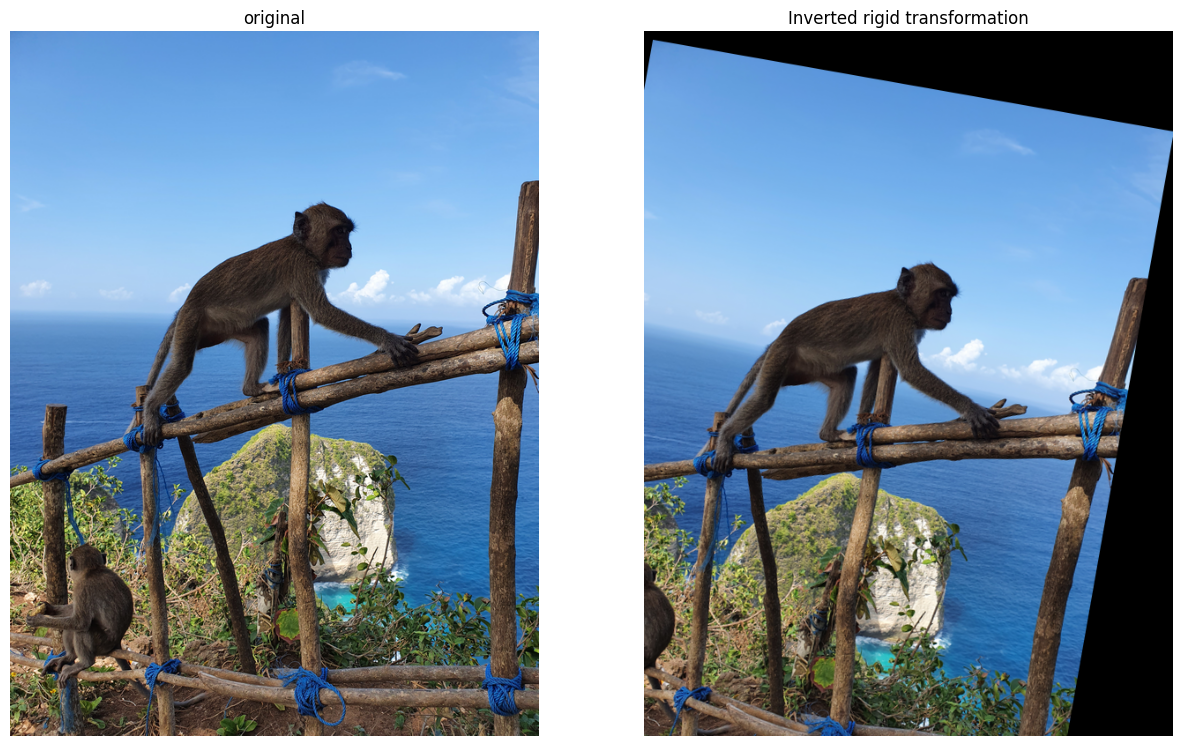

In [24]:
#Lx-7.5 Compute and apply the inverse of a transform 

rotation_angle = 10.0 * math.pi / 180.
trans = [10, 10]
tform = EuclideanTransform(rotation=rotation_angle, translation=trans)
transformed_img = warp(img, tform.inverse)


from utils import plot_comparison
plot_comparison(img, transformed_img, "Inverted rigid transformation", 15,15)

In [5]:
#Lx-7.5 Construct a similarity (translation, rotation, plus scale) transform using skimage.transform.SimilarityTransform
import math

rotation_angle = 15.0 * math.pi / 180.
trans = [40, 30]
scale = 0.6
tform = SimilarityTransform(scale = scale, rotation = rotation_angle, translation = trans)

recovered_img = warp(transformed_img, tform)
plot_comparison(im_org, recovered_img, "Similarity transformation")


NameError: name 'transformed_img' is not defined

In [ ]:
#Lx-7.6 Use the skimage.transform.swirl to transform images
strength = 10
rad = 300
c = [500, 400]
swirl_img = swirl(im_org, strength=strength, radius=rad, center=c)
show_comparison(im_org, swirl_img, 'Swirl transformation')


/tmp/ipykernel_438459/3577641913.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(blend)
/tmp/ipykernel_438459/3577641913.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


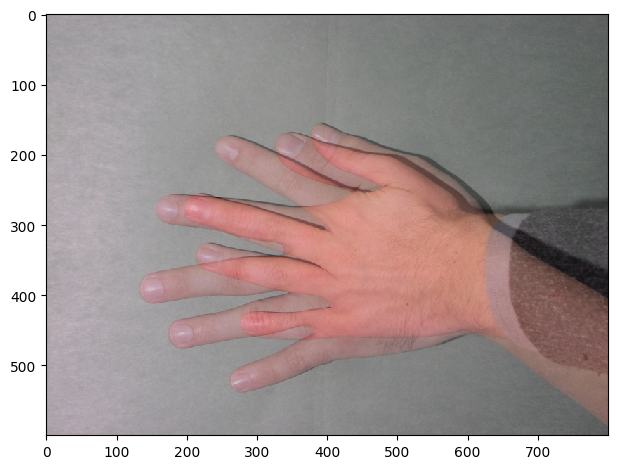

In [29]:
#Lx-7.7 Compute and visualize the blend of two images
src_img = io.imread(path + "Hand1.jpg")
dst_img = io.imread(path + "Hand2.jpg")

from skimage import img_as_float
blend = 0.5 * img_as_float(src_img) + 0.5 * img_as_float(dst_img)

io.imshow(blend)
io.show()





[[588 274]
 [328 179]
 [134 398]
 [260 525]
 [613 448]]
[588 328 134 260 613]


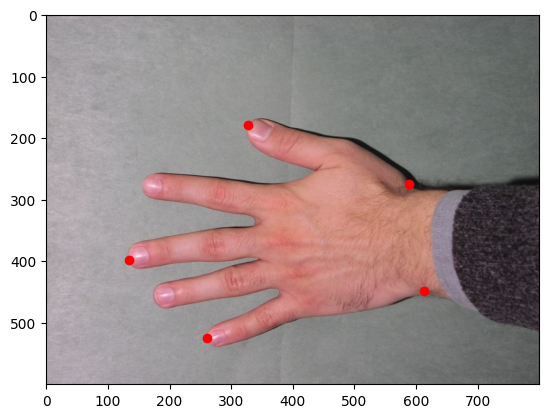

In [ ]:
#Lx-7.8 Manually place landmarks on an image
#Lx-7.9 Visualize sets of landmarks on images
import numpy as np
src = np.array([[588, 274], [328, 179], [134, 398], [260, 525], [613, 448]])


plt.imshow(src_img)
plt.plot(src[:, 0], src[:, 1], '.r', markersize=12)
plt.show()

In [6]:
#Lx-7.10 Compute the objective function between two sets of landmarks

%matplotlib qt 
plt.imshow(src_img)
plt.show()

%matplotlib inline

plt.close()

dst = np.array([[621, 293], [382, 166], [198, 266], [270, 440], [600, 450]])
fig, ax = plt.subplots()
ax.plot(src[:, 0], src[:, 1], '-r', markersize=12, label="Source")
ax.plot(dst[:, 0], dst[:, 1], '-g', markersize=12, label="Destination")
ax.invert_yaxis()
ax.legend()
ax.set_title("Landmarks before alignment")
plt.show()


f = np.sum((src - dst) ** 2)


NameError: name 'src_img' is not defined

In [ ]:
#Lx-7.11 Use the estimate function to estimate the optimal transformation between two sets of landmarks
tform = EuclideanTransform()
tform.estimate(src, dst)


In [ ]:
#Lx-7.12 Use the skimage.transform.matrix_transform to transform a set of landmarks
src_transform = matrix_transform(src,tform.params)
print(f)